In [2]:
library(miloDE)

library(BiocParallel)
ncores = 16
mcparam = MulticoreParam(workers = ncores)
register(mcparam)

In [44]:
library(miloDE)

# library containing toy data
suppressMessages(library(MouseGastrulationData))

# analysis libraries
library(scuttle)
suppressMessages(library(miloR))
suppressMessages(library(uwot))
library(scran)
suppressMessages(library(dplyr))
library(reshape2)

# packages for gene cluster analysis
library(scWGCNA)
#> 
suppressMessages(library(Seurat))

# plotting libraries
library(ggplot2)
library(viridis)
#> Loading required package: viridisLite
library(ggpubr)

In [48]:
EmbryoCelltypeColours = c(
"Epiblast" = "#635547",
  "Primitive_Streak" = "#DABE99",
  "Caudal_epiblast" = "#9e6762",
  "PGC" = "#FACB12",
  "Anterior_Primitive_Streak" = "#c19f70",
  "Notochord" = "#0F4A9C",
  "Def._endoderm" = "#F397C0",
  "Gut" = "#EF5A9D",
  "Nascent_mesoderm" = "#C594BF",
  "Mixed_mesoderm" = "#DFCDE4",
  "Intermediate_mesoderm" = "#139992",
  "Caudal_Mesoderm" = "#3F84AA",
  "Paraxial_mesoderm" = "#8DB5CE",
  "Somitic_mesoderm" = "#005579",
  "Pharyngeal_mesoderm" = "#C9EBFB",
  "Cardiomyocytes" = "#B51D8D",
  "Allantois" = "#532C8A",
  "ExE_mesoderm" = "#8870ad",
  "Mesenchyme" = "#cc7818",
  "Haematoendothelial_progenitors" = "#FBBE92",
  "Endothelium" = "#ff891c",
  "Blood_progenitors" = "#c9a997",
  "Blood_progenitors_1" = "#f9decf",
  "Blood_progenitors_2" = "#c9a997",
  "Erythroid" = "#EF4E22",
  "Erythroid1" = "#C72228",
  "Erythroid2" = "#f79083",
  "Erythroid3" = "#EF4E22",
  "NMP" = "#8EC792",
  "Neurectoderm" = "#65A83E",
  "Rostral_neurectoderm" = "#65A83E",
  "Caudal_neurectoderm" = "#354E23",
  "Neural_crest" = "#C3C388",
  "Forebrain_Midbrain_Hindbrain" = "#647a4f",
  "Spinal_cord" = "#CDE088",
  "Surface_ectoderm" = "#f7f79e",
  "Visceral_endoderm" = "#F6BFCB",
  "ExE_endoderm" = "#7F6874",
  "ExE_ectoderm" = "#989898",
  "Parietal_endoderm" = "#1A1A1A"
)


In [45]:
# load chimera Tal1
sce = suppressMessages(MouseGastrulationData::Tal1ChimeraData())

In [47]:
unique(sce$celltype.mapped )

[1] "Haematoendothelial_progenitors" "Spinal_cord"                   
[3] "Endothelium"                    "Blood_progenitors_2"           
[5] "Blood_progenitors_1"

In [ ]:
# downsample to few selected cell types
cts = c("Spinal cord" , "Haematoendothelial progenitors", "Endothelium" , "Blood progenitors 1" , "Blood progenitors 2")
sce = sce[, sce$celltype.mapped %in% cts]
# let's rename Haematoendothelial progenitors
#sce$celltype.mapped[sce$celltype.mapped == "Haematoendothelial progenitors"] = "Haem. prog-s."
sce$celltype.mapped = gsub(' ', '_', gsub('-', '_', gsub('/', '_', sce$celltype.mapped)))
# delete row for tomato
sce = sce[!rownames(sce) == "tomato-td" , ]

# add logcounts
sce = logNormCounts(sce)

# update tomato field to be more interpretable 
sce$tomato = sapply(sce$tomato , function(x) ifelse(isTRUE(x) , "Tal1_KO" , "WT"))

# for this exercise, we focus on 3000 highly variable genes (for computational efficiency)
dec.sce = modelGeneVar(sce)
hvg.genes = getTopHVGs(dec.sce, n = 3000)
sce = sce[hvg.genes , ]
# change rownames to symbol names
rowdata = as.data.frame(rowData(sce))
rownames(sce) = rowdata$SYMBOL

# add UMAPs
set.seed(32)
umaps = as.data.frame(uwot::umap(reducedDim(sce , "pca.corrected")))
# let's store UMAPs - we will use them for visualisation
reducedDim(sce , "UMAP") = umaps

# plot UMAPs, colored by cell types
umaps = cbind(as.data.frame(colData(sce)) , reducedDim(sce , "UMAP"))
#names(EmbryoCelltypeColours)[names(EmbryoCelltypeColours) == "Haematoendothelial_progenitors"] = "Haem. prog-s."


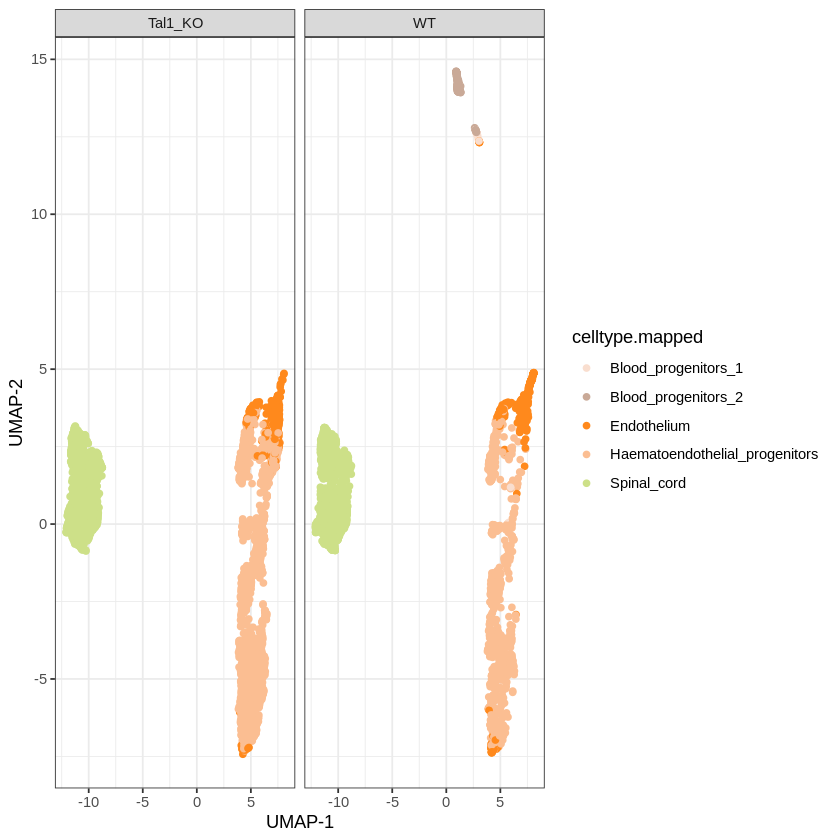

In [50]:
cols_ct = EmbryoCelltypeColours[names(EmbryoCelltypeColours) %in% unique(umaps$celltype.mapped)]

p = ggplot(umaps , aes(x = V1 , y = V2 , col = celltype.mapped)) +
  geom_point() + 
  scale_color_manual(values = cols_ct) +
  facet_wrap(~tomato) +
  theme_bw() + 
  labs(x = "UMAP-1", y = "UMAP-2")
p

Running for next k values:
10, 15, 20, 25, 30, 35, 40



100% covered by 106 sets.


Finished for k = 10



100% covered by 57 sets.


Finished for k = 15



...

Finished for k = 30



100% covered by 28 sets.


Finished for k = 35



100% covered by 26 sets.


Finished for k = 40

Finished the estimation of neighbourhood sizes ~ k dependancy (order = 2).



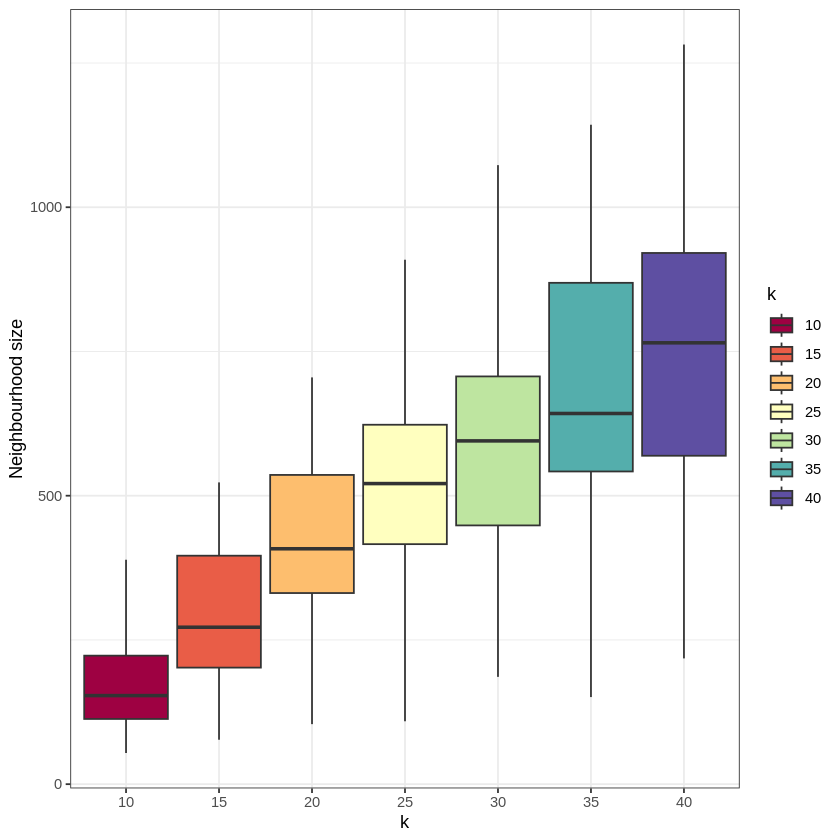

In [51]:
stat_k = estimate_neighbourhood_sizes(sce, k_grid = seq(10,40,5) , 
                                      order = 2, prop = 0.1 , filtering = TRUE,
                                      reducedDim_name = "pca.corrected" , plot_stat = TRUE)


In [52]:
set.seed(32)
sce_milo = assign_neighbourhoods(sce , k = 20 , order = 2, 
                                 filtering = TRUE , reducedDim_name = "pca.corrected" , verbose = F)
#> 100% covered by 42 sets.

100% covered by 42 sets.


In [53]:
nhoods_sce = nhoods(sce_milo)
# assign cell types for nhoods 
nhood_stat_ct = data.frame(Nhood = 1:ncol(nhoods_sce) , Nhood_center = colnames(nhoods_sce))
nhood_stat_ct = miloR::annotateNhoods(sce_milo , nhood_stat_ct , coldata_col = "celltype.mapped")
#> Converting celltype.mapped to factor...
p = plot_milo_by_single_metric(sce_milo, nhood_stat_ct, colour_by = "celltype.mapped" , 
                                      layout = "UMAP" , size_range = c(1.5,3) , edge_width = c(0.2,0.5)) + 
  scale_fill_manual(values = cols_ct , name = "Cell type")

Converting celltype.mapped to factor...

Warning message in plot_milo_by_single_metric(sce_milo, nhood_stat_ct, colour_by = "celltype.mapped", :
“Coercing layout to matrix format”
Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.


In [57]:
options(repr.plot.height=5)

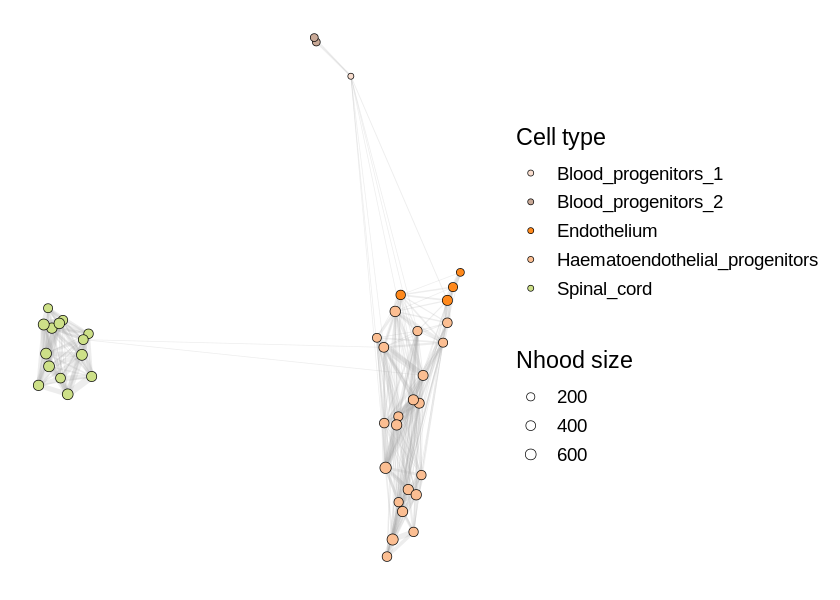

In [58]:
p

In [59]:
stat_auc = suppressWarnings(calc_AUC_per_neighbourhood(sce_milo , sample_id = "sample" , condition_id = "tomato", min_n_cells_per_sample = 1, BPPARAM = mcparam))

p = plot_milo_by_single_metric(sce_milo, stat_auc, colour_by = "auc" , 
                                      layout = "UMAP" , size_range = c(1.5,3) , edge_width = c(0.2,0.5)) + 
  scale_fill_viridis(name = "AUC")

Warning message in plot_milo_by_single_metric(sce_milo, stat_auc, colour_by = "auc", :
“Coercing layout to matrix format”
Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.


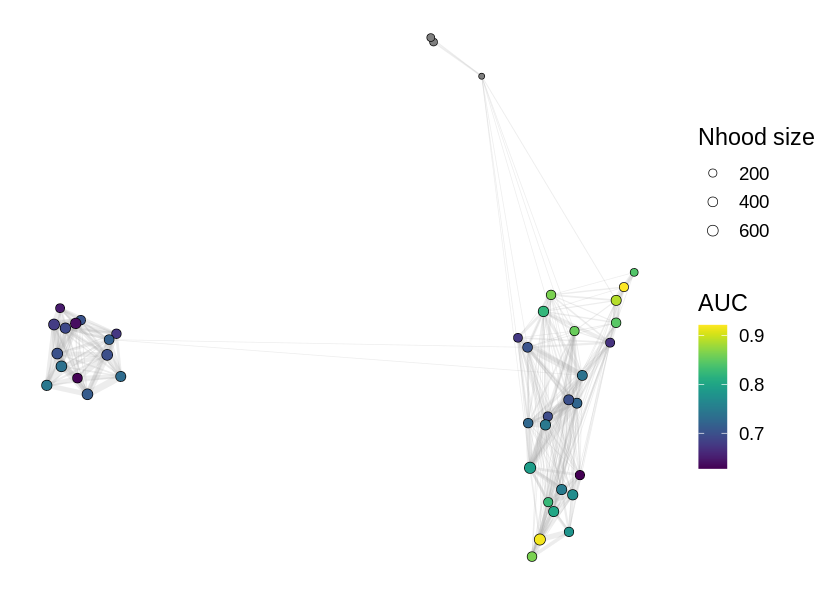

In [60]:
p

Starting DE testing within each neighbourhood:

R_zmq_msg_send errno: 4 strerror: Interrupted system call
R_zmq_msg_send errno: 4 strerror: Interrupted system call
R_zmq_msg_send errno: 4 strerror: Interrupted system call


R_zmq_msg_send errno: 4 strerror: Interrupted system call
R_zmq_msg_send errno: 4 strerror: Interrupted system call
R_zmq_msg_send errno: 4 strerror: Interrupted system call


R_zmq_msg_send errno: 4 strerror: Interrupted system call
R_zmq_msg_send errno: 4 strerror: Interrupted system call
R_zmq_msg_send errno: 4 strerror: Interrupted system call


R_zmq_msg_send errno: 4 strerror: Interrupted system call
R_zmq_msg_send errno: 4 strerror: Interrupted system call
R_zmq_msg_send errno: 4 strerror: Interrupted system call


R_zmq_msg_send errno: 4 strerror: Interrupted system call
R_zmq_msg_send errno: 4 strerror: Interrupted system call
R_zmq_msg_send errno: 4 strerror: Interrupted system call


R_zmq_msg_send errno: 4 strerror: Interrupted system call
R_zmq_msg_send

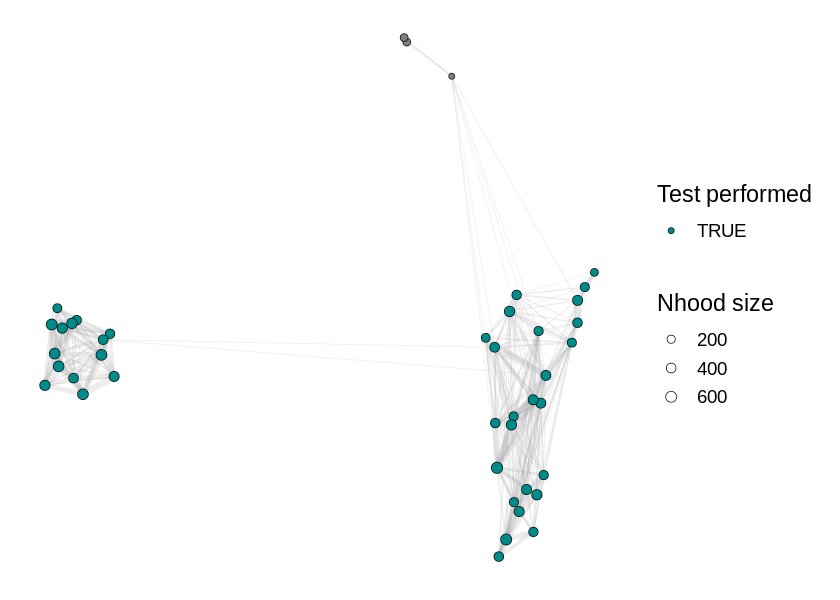

In [61]:
de_stat = de_test_neighbourhoods(sce_milo ,
                             sample_id = "sample",
                             design = ~tomato,
                             covariates = c("tomato"),
                             subset_nhoods = stat_auc$Nhood[!is.na(stat_auc$auc)],
                             output_type = "SCE",
                             plot_summary_stat = TRUE,
                             layout = "UMAP", BPPARAM = mcparam , 
                             verbose = T)

Warning message in plot_milo_by_single_metric(sce_milo, stat_de_magnitude, colour_by = "n_DE_genes", :
“Coercing layout to matrix format”
Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.
Warning message in plot_milo_by_single_metric(sce_milo, stat_de_magnitude, colour_by = "n_specific_DE_genes", :
“Coercing layout to matrix format”
Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.


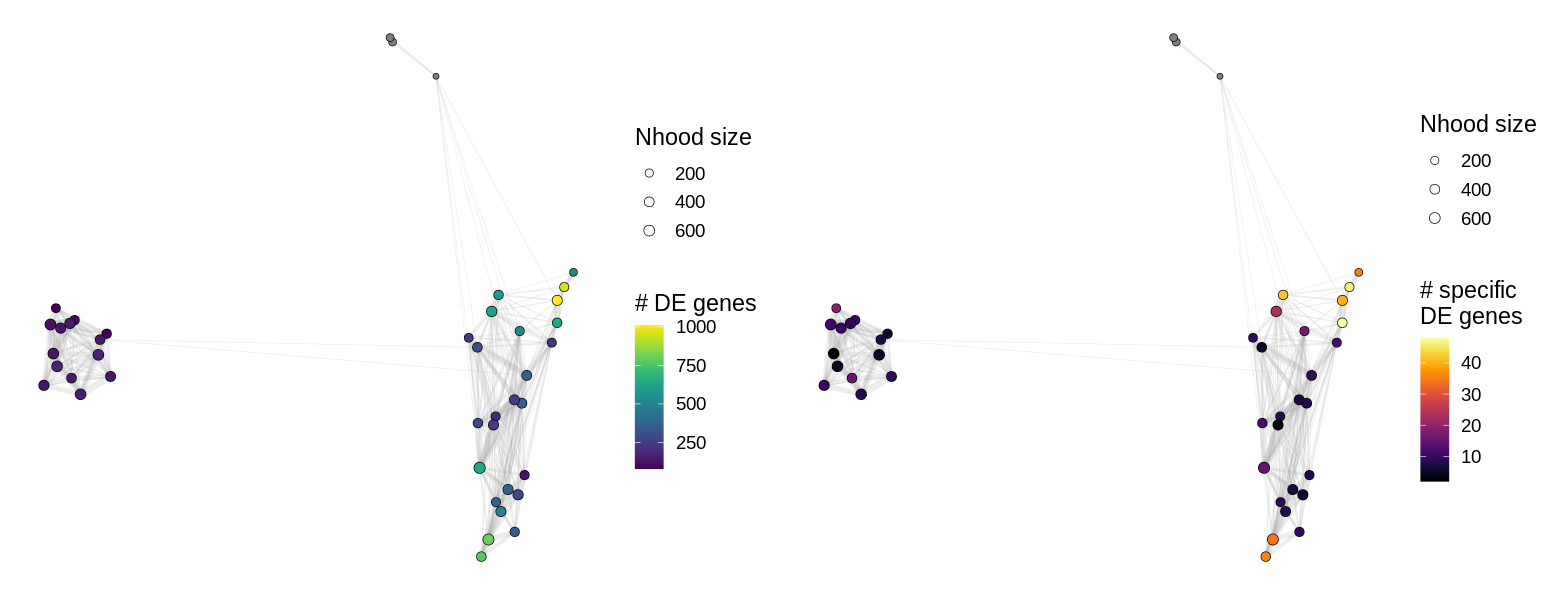

In [63]:
stat_de_magnitude = rank_neighbourhoods_by_DE_magnitude(de_stat)

p1 = plot_milo_by_single_metric(sce_milo, stat_de_magnitude, colour_by = "n_DE_genes" , 
                                      layout = "UMAP" , size_range = c(1.5,3) , edge_width = c(0.2,0.5)) + 
  scale_fill_viridis(name = "# DE genes")
#> Warning in plot_milo_by_single_metric(sce_milo, stat_de_magnitude, colour_by =
#> "n_DE_genes", : Coercing layout to matrix format
#> Scale for 'fill' is already present. Adding another scale for 'fill', which
#> will replace the existing scale.
p2 = plot_milo_by_single_metric(sce_milo, stat_de_magnitude, colour_by = "n_specific_DE_genes" , 
                                      layout = "UMAP" , size_range = c(1.5,3) , edge_width = c(0.2,0.5)) + 
  scale_fill_viridis(name = "# specific\nDE genes" , option = "inferno")
#> Warning in plot_milo_by_single_metric(sce_milo, stat_de_magnitude, colour_by =
#> "n_specific_DE_genes", : Coercing layout to matrix format
#> Scale for 'fill' is already present. Adding another scale for 'fill', which
#> will replace the existing scale.
p = ggarrange(p1,p2)
options(repr.plot.height=5, repr.plot.width=13)
p

Warning message in eval(predvars, data, env):
“NaNs produced”


[1] "We have 1070 genes in the variable genes object"


Warning message:
“executing %dopar% sequentially: no parallel backend registered”
Warning message in (function (x, y = NULL, robustX = TRUE, robustY = TRUE, use = "all.obs", :
“bicor: zero MAD in variable 'x'. Pearson correlation was used for individual columns with zero (or missing) MAD.”
Warning message in (function (x, y = NULL, robustX = TRUE, robustY = TRUE, use = "all.obs", :
“bicor: zero MAD in variable 'y'. Pearson correlation was used for individual columns with zero (or missing) MAD.”


   Power SFT.R.sq slope truncated.R.sq mean.k. median.k. max.k.
1      1   0.0342  3.73          0.871 536.000   536.000 559.00
2      2   0.3410 -7.76          0.884 293.000   290.000 342.00
3      3   0.4240 -4.68          0.925 171.000   169.000 233.00
4      4   0.4770 -3.19          0.946 106.000   103.000 169.00
5      5   0.5460 -2.53          0.958  68.300    65.100 128.00
6      6   0.5870 -2.33          0.934  46.000    42.900 100.00
7      7   0.5990 -2.12          0.918  32.000    28.900  79.90
8      8   0.6370 -1.95          0.915  23.000    19.900  64.80
9      9   0.6290 -1.94          0.894  16.900    14.100  53.40
10    10   0.6540 -1.84          0.887  12.800    10.200  44.50
11    12   0.7950 -1.56          0.946   7.670     5.600  31.80
12    14   0.9080 -1.46          0.997   4.920     3.230  24.20
13    16   0.9170 -1.51          0.988   3.320     1.930  19.80
14    18   0.9290 -1.56          0.993   2.330     1.190  16.60
15    20   0.9350 -1.59          0.986  

Warning message in (function (x, y = NULL, robustX = TRUE, robustY = TRUE, use = "all.obs", :
“bicor: zero MAD in variable 'x'. Pearson correlation was used for individual columns with zero (or missing) MAD.”


...

TOM calculation: adjacency..
..will not use multithreading.
 Fraction of slow calculations: 0.000000
..connectivity..
..matrix multiplication (system BLAS)..
..normalization..
..done.
[1] "my.height:  0.9968  .... my.Clsize:  30"
 mergeCloseModules: Merging modules whose distance is less than 0.25
   multiSetMEs: Calculating module MEs.
     Working on set 1 ...
     moduleEigengenes: Calculating 7 module eigengenes in given set.
   multiSetMEs: Calculating module MEs.
     Working on set 1 ...
     moduleEigengenes: Calculating 4 module eigengenes in given set.
   Calculating new MEs...
   multiSetMEs: Calculating module MEs.
     Working on set 1 ...
     moduleEigengenes: Calculating 4 module eigengenes in given set.
0 genes not assigned to any module.
31 genes excluded due to significance.

Warning message in (function (x, y = NULL, robustX = TRUE, robustY = TRUE, use = "all.obs", :
“bicor: zero MAD in variable 'x'. Pearson correlation was used for individual columns with zero (or missing) MAD.”


TOM calculation: adjacency..
..will not use multithreading.
 Fraction of slow calculations: 0.000000
..connectivity..
..matrix multiplication (system BLAS)..
..normalization..
..done.
[1] "my.height:  0.9961  .... my.Clsize:  30"
 mergeCloseModules: Merging modules whose distance is less than 0.25
   multiSetMEs: Calculating module MEs.
     Working on set 1 ...
     moduleEigengenes: Calculating 7 module eigengenes in given set.
   multiSetMEs: Calculating module MEs.
     Working on set 1 ...
     moduleEigengenes: Calculating 4 module eigengenes in given set.
   Calculating new MEs...
   multiSetMEs: Calculating module MEs.
     Working on set 1 ...
     moduleEigengenes: Calculating 4 module eigengenes in given set.
0 genes not assigned to any module.
2 genes excluded due to significance.

Warning message in (function (x, y = NULL, robustX = TRUE, robustY = TRUE, use = "all.obs", :
“bicor: zero MAD in variable 'x'. Pearson correlation was used for individual columns with zero (or missing) MAD.”


TOM calculation: adjacency..
..will not use multithreading.
 Fraction of slow calculations: 0.000000
..connectivity..
..matrix multiplication (system BLAS)..
..normalization..
..done.
[1] "my.height:  0.9962  .... my.Clsize:  30"
 mergeCloseModules: Merging modules whose distance is less than 0.25
   multiSetMEs: Calculating module MEs.
     Working on set 1 ...
     moduleEigengenes: Calculating 7 module eigengenes in given set.
   multiSetMEs: Calculating module MEs.
     Working on set 1 ...
     moduleEigengenes: Calculating 4 module eigengenes in given set.
   Calculating new MEs...
   multiSetMEs: Calculating module MEs.
     Working on set 1 ...
     moduleEigengenes: Calculating 4 module eigengenes in given set.
0 genes not assigned to any module.
0 genes excluded due to significance.

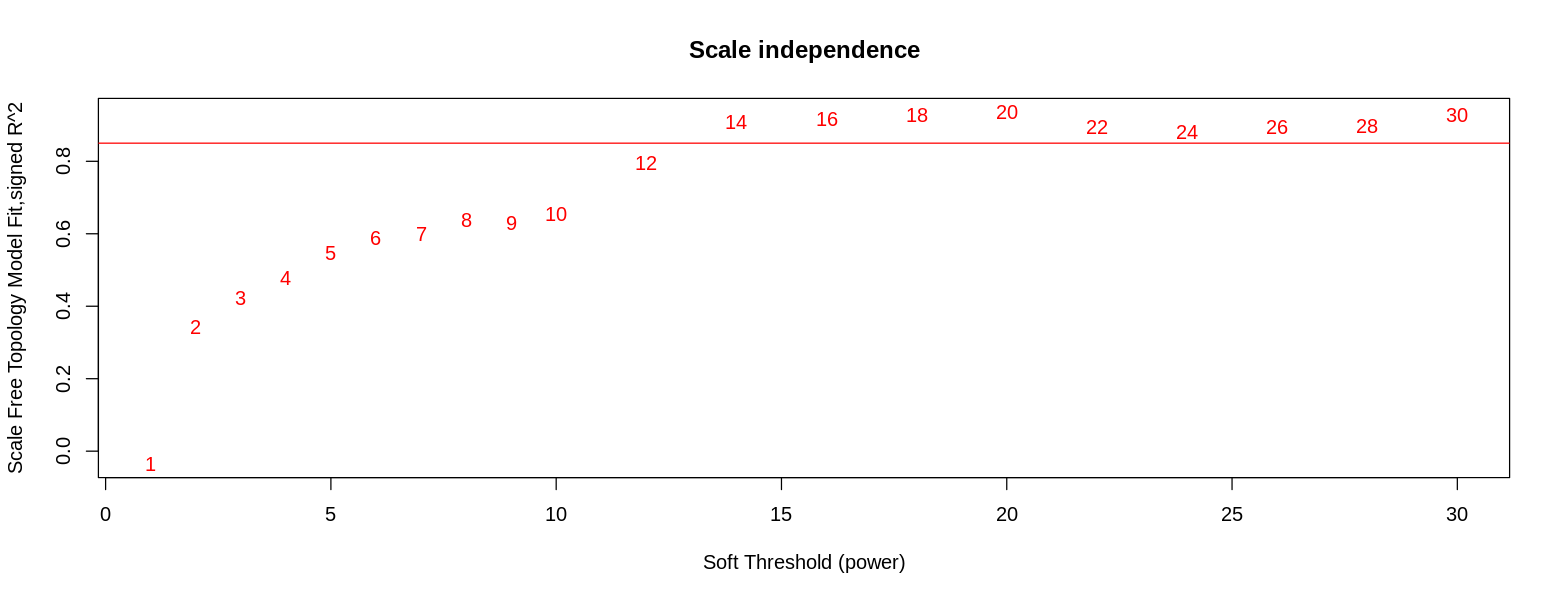

In [64]:
get_wgcna_modules = function(de_stat , subset_hoods = NULL , 
                             n_hoods_sig.thresh = 2 ,
                             npcs = 5 ,
                             pval.thresh = 0.1 ){
  require(scWGCNA)
  require(Seurat)
  require(dplyr)
  require(reshape2)
  
  set.seed(32)
  # subset hoods
  if (!is.null(subset_hoods)){
    de_stat = de_stat[de_stat$Nhood %in% subset_hoods , ]
  }
  
  # focus on genes that DE in at least 2 nhoods
  de_stat_per_gene = as.data.frame(de_stat %>% group_by(gene) %>% dplyr::summarise(n_hoods_sig = sum(pval_corrected_across_nhoods < pval.thresh , na.rm = TRUE)))
  genes_sig = de_stat_per_gene$gene[de_stat_per_gene$n_hoods_sig >= n_hoods_sig.thresh]
  
  de_stat = de_stat[de_stat$gene %in% genes_sig, ]
  de_stat = de_stat[order(de_stat$Nhood) , ]
  
  # discard neighbourhoods in which testing was not performed
  de_stat = de_stat[de_stat$test_performed , ]
  
  # for this analysis, set logFC to 0 and pvals to 1 if they are NaN
  de_stat$logFC[is.na(de_stat$logFC)] = 0
  de_stat$pval[is.na(de_stat$pval)] = 1
  de_stat$pval_corrected_across_genes[is.na(de_stat$pval_corrected_across_genes)] = 1
  de_stat$pval_corrected_across_nhoods[is.na(de_stat$pval_corrected_across_nhoods)] = 1
  
  # set logFC to 0 if pval_corrected_across_nhoods > pval.thresh
  de_stat$logFC[de_stat$pval_corrected_across_nhoods >= pval.thresh] = 0
  
  # move the object to Seurat
  de_stat = reshape2::dcast(data = de_stat, formula = gene~Nhood, value.var = "logFC")
  rownames(de_stat) = de_stat$gene
  de_stat = de_stat[,2:ncol(de_stat)]
  
  obj.seurat <- CreateSeuratObject(counts = de_stat)
  DefaultAssay(obj.seurat) <- "RNA"
  obj.seurat = FindVariableFeatures(obj.seurat)
  # scale
  obj.seurat[["RNA"]]@scale.data = as.matrix(obj.seurat[["RNA"]]@data)
  obj.seurat = RunPCA(obj.seurat , npcs = npcs)
  
  # run scwgcna
  clusters_scwgcna = run.scWGCNA(p.cells = obj.seurat, 
                                 s.cells = obj.seurat, 
                                 is.pseudocell = F, 
                                 features = rownames(obj.seurat),
                                 less = TRUE , merging = TRUE)
  # compile stat
  clusters = lapply(1:length(clusters_scwgcna$module.genes) , function(i){
    out = data.frame(cluster = i , gene = clusters_scwgcna$module.genes[[i]] , n_genes = length(clusters_scwgcna$module.genes[[i]]))
    return(out)
  })
  clusters = do.call(rbind , clusters)
  # add colors
  genes_w_colors = clusters_scwgcna$dynamicCols
  genes_w_colors = data.frame(gene = names(genes_w_colors) , cluster_color = genes_w_colors)
  clusters = merge(clusters , genes_w_colors)
  
  return(clusters)
}


# for this vignette, for simplicity we will focus on genes that are DE in at least 4 neighbourhoods
modules_wgcna = suppressMessages(get_wgcna_modules(convert_de_stat(de_stat) , n_hoods_sig.thresh = 4))

In [65]:
plots = lapply(sort(unique(modules_wgcna$cluster)) , function(cluster){
  p = plot_DE_gene_set(sce_milo, de_stat , genes = modules_wgcna$gene[modules_wgcna$cluster == cluster],
                            layout = "UMAP" , size_range = c(0.5,3) ,
                            node_stroke = 0.3, edge_width = c(0.2,0.5)) +
    ggtitle(paste0("Module ", cluster, ", ", length(modules_wgcna$gene[modules_wgcna$cluster == cluster]) , " genes"))
  return(p)
})

Warning message in plot_milo_by_single_metric(x, nhood_stat, colour_by = "avg_logFC", :
“Coercing layout to matrix format”
Warning message in plot_milo_by_single_metric(x, nhood_stat, colour_by = "avg_logFC", :
“Coercing layout to matrix format”
Warning message in plot_milo_by_single_metric(x, nhood_stat, colour_by = "avg_logFC", :
“Coercing layout to matrix format”
Warning message in plot_milo_by_single_metric(x, nhood_stat, colour_by = "avg_logFC", :
“Coercing layout to matrix format”


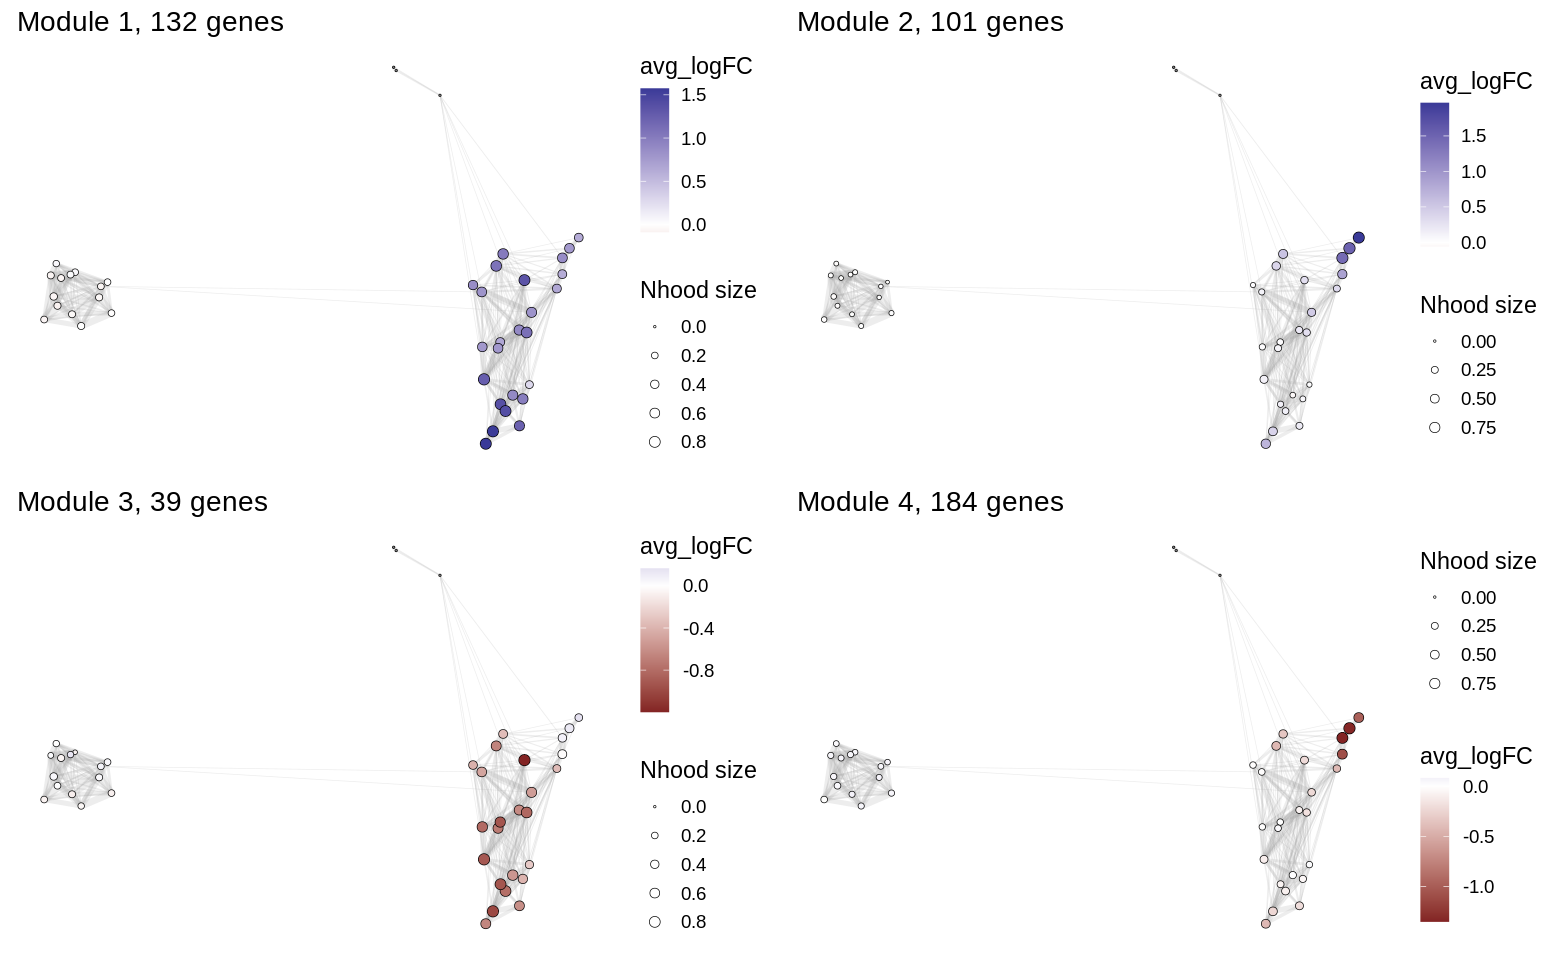

In [67]:
options(repr.plot.height=8, repr.plot.width=13)
p = ggarrange(plotlist = plots)
p

Converting de_stat to 'data.frame' format

Converting de_stat to 'SingleCellExperiment' format

Converting de_stat to 'SingleCellExperiment' format

Converting de_stat to 'SingleCellExperiment' format

Converting de_stat to 'SingleCellExperiment' format



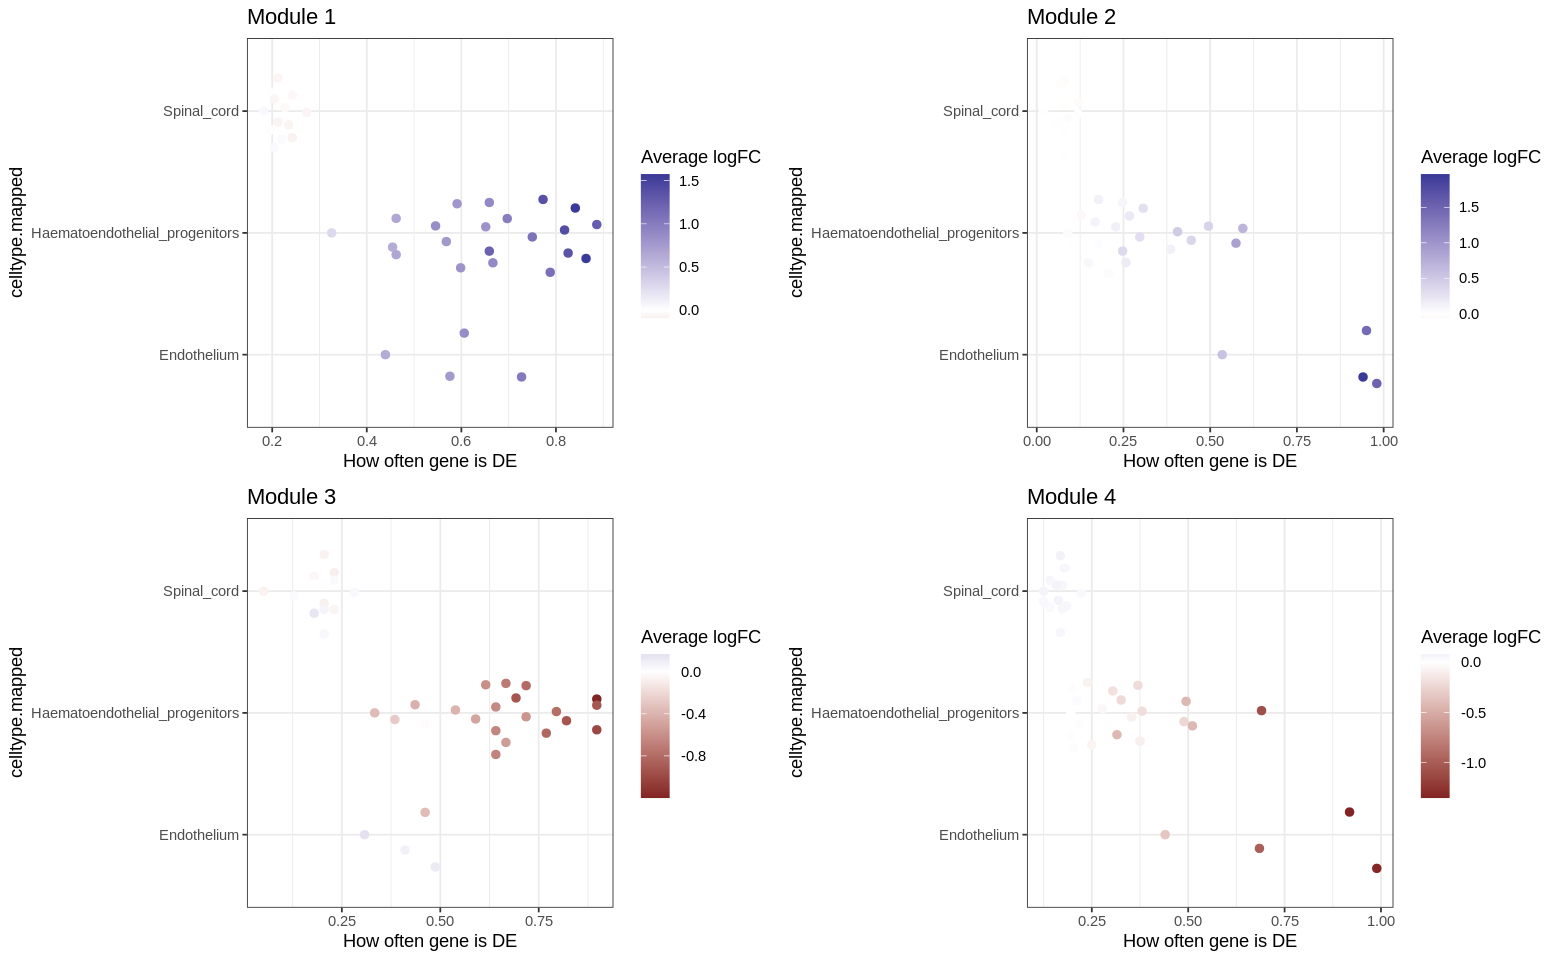

In [68]:
# we first need to assign cell type label to each neighbourhood - we have calculated it previously
# we will use data.frame format for de-stat; the conversion between SingleCellExperiment and data.frame formats can be done using `convert_de_stat`
de_stat_df = convert_de_stat(de_stat)
#> Converting de_stat to 'data.frame' format
de_stat_df = merge(de_stat_df , nhood_stat_ct , by = c("Nhood" , "Nhood_center"))


plots = lapply(sort(unique(modules_wgcna$cluster)) , function(cluster){
  p = plot_beeswarm_gene_set(de_stat_df, 
                             genes = modules_wgcna$gene[modules_wgcna$cluster == cluster], 
                             nhoodGroup = "celltype.mapped") + 
    ggtitle(paste0("Module ", cluster))
  return(p)
})
#> Converting de_stat to 'SingleCellExperiment' format
#> Converting de_stat to 'SingleCellExperiment' format
#> Converting de_stat to 'SingleCellExperiment' format
#> Converting de_stat to 'SingleCellExperiment' format
p = ggarrange(plotlist = plots)
p

Converting de_stat to 'data.frame' format

Warning message in plot_milo_by_single_metric(x, nhood_stat = nhood_stat, colour_by = "logFC", :
“Coercing layout to matrix format”
Converting de_stat to 'data.frame' format

Warning message in plot_milo_by_single_metric(x, nhood_stat = nhood_stat, colour_by = "logFC", :
“Coercing layout to matrix format”
Converting de_stat to 'data.frame' format

Warning message in plot_milo_by_single_metric(x, nhood_stat = nhood_stat, colour_by = "logFC", :
“Coercing layout to matrix format”
Converting de_stat to 'data.frame' format

Warning message in plot_milo_by_single_metric(x, nhood_stat = nhood_stat, colour_by = "logFC", :
“Coercing layout to matrix format”
Converting de_stat to 'data.frame' format

Warning message in plot_milo_by_single_metric(x, nhood_stat = nhood_stat, colour_by = "logFC", :
“Coercing layout to matrix format”
Converting de_stat to 'data.frame' format

Warning message in plot_milo_by_single_metric(x, nhood_stat = nhood_stat, colour_b

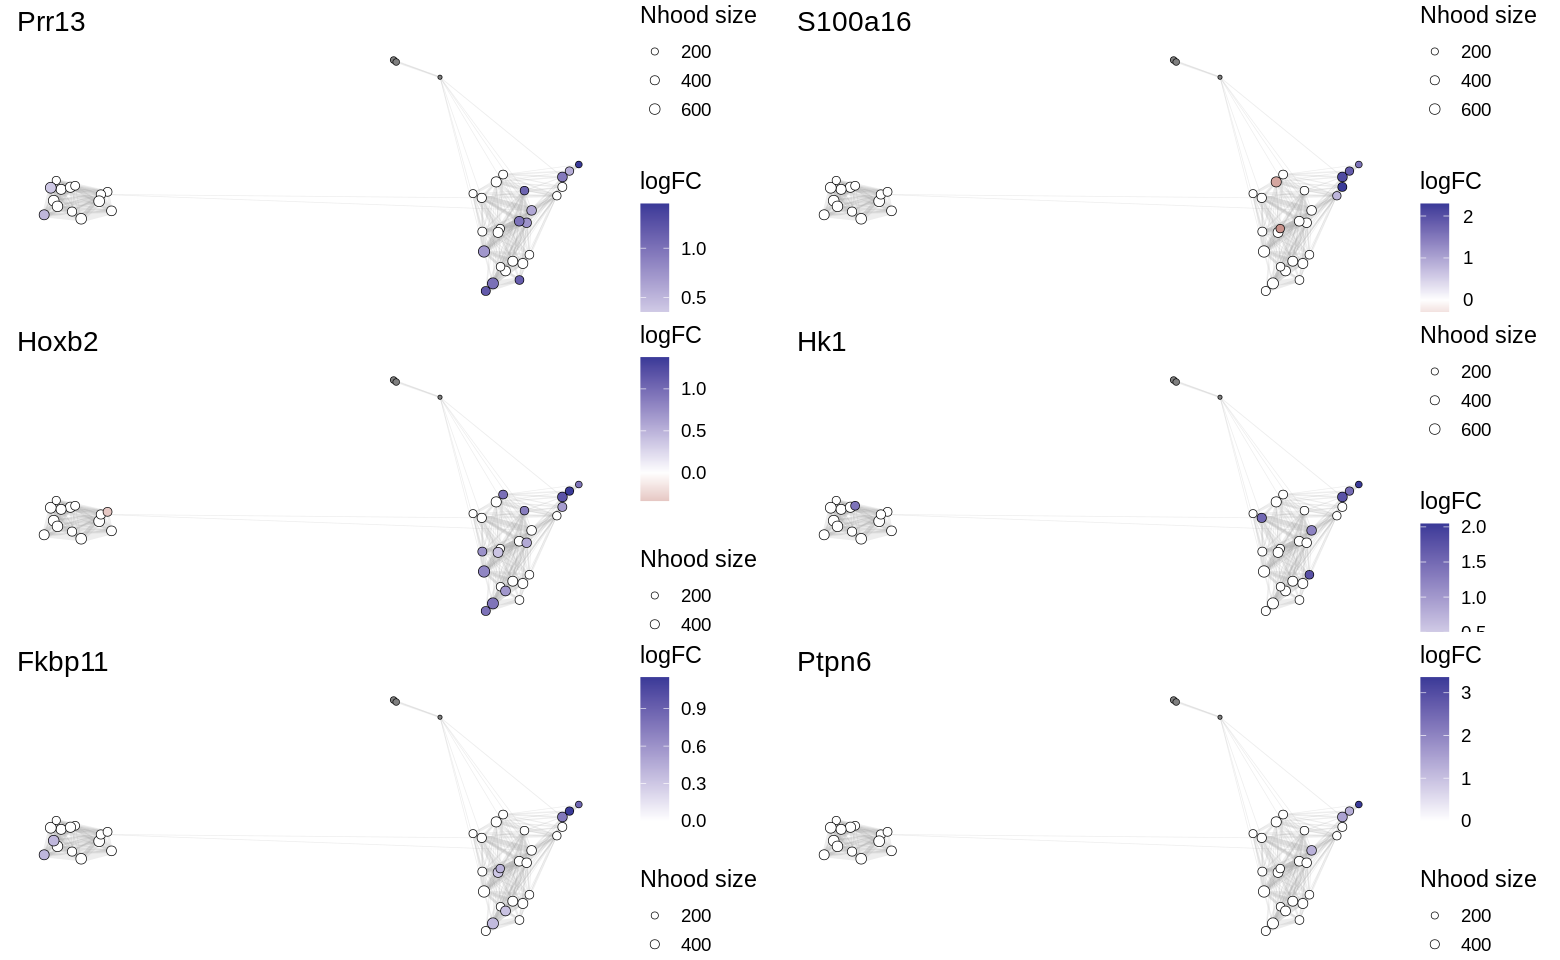

In [69]:
set.seed(1020)
module = 2
n_genes = 6
genes = sample(modules_wgcna$gene[modules_wgcna$cluster == module] , n_genes)


plots = lapply(genes , function(gene){
  p = plot_DE_single_gene(sce_milo, de_stat , gene = gene , layout = "UMAP" , set_na_to_0 = TRUE) + 
    ggtitle(gene)
  return(p)
})
#> Converting de_stat to 'data.frame' format
#> Warning in plot_milo_by_single_metric(x, nhood_stat = nhood_stat, colour_by =
#> "logFC", : Coercing layout to matrix format
#> Converting de_stat to 'data.frame' format
#> Warning in plot_milo_by_single_metric(x, nhood_stat = nhood_stat, colour_by =
#> "logFC", : Coercing layout to matrix format
#> Converting de_stat to 'data.frame' format
#> Warning in plot_milo_by_single_metric(x, nhood_stat = nhood_stat, colour_by =
#> "logFC", : Coercing layout to matrix format
#> Converting de_stat to 'data.frame' format
#> Warning in plot_milo_by_single_metric(x, nhood_stat = nhood_stat, colour_by =
#> "logFC", : Coercing layout to matrix format
#> Converting de_stat to 'data.frame' format
#> Warning in plot_milo_by_single_metric(x, nhood_stat = nhood_stat, colour_by =
#> "logFC", : Coercing layout to matrix format
#> Converting de_stat to 'data.frame' format
#> Warning in plot_milo_by_single_metric(x, nhood_stat = nhood_stat, colour_by =
#> "logFC", : Coercing layout to matrix format
p = ggarrange(plotlist = plots , ncol = 2, nrow = 3)
p

Converting de_stat to 'data.frame' format

Warning message in plot_milo_by_single_metric(x, nhood_stat = nhood_stat, colour_by = "logFC", :
“Coercing layout to matrix format”
Converting de_stat to 'data.frame' format

Warning message in plot_milo_by_single_metric(x, nhood_stat = nhood_stat, colour_by = "logFC", :
“Coercing layout to matrix format”
Converting de_stat to 'data.frame' format

Warning message in plot_milo_by_single_metric(x, nhood_stat = nhood_stat, colour_by = "logFC", :
“Coercing layout to matrix format”
Converting de_stat to 'data.frame' format

Warning message in plot_milo_by_single_metric(x, nhood_stat = nhood_stat, colour_by = "logFC", :
“Coercing layout to matrix format”
Converting de_stat to 'data.frame' format

Warning message in plot_milo_by_single_metric(x, nhood_stat = nhood_stat, colour_by = "logFC", :
“Coercing layout to matrix format”
Converting de_stat to 'data.frame' format

Warning message in plot_milo_by_single_metric(x, nhood_stat = nhood_stat, colour_b

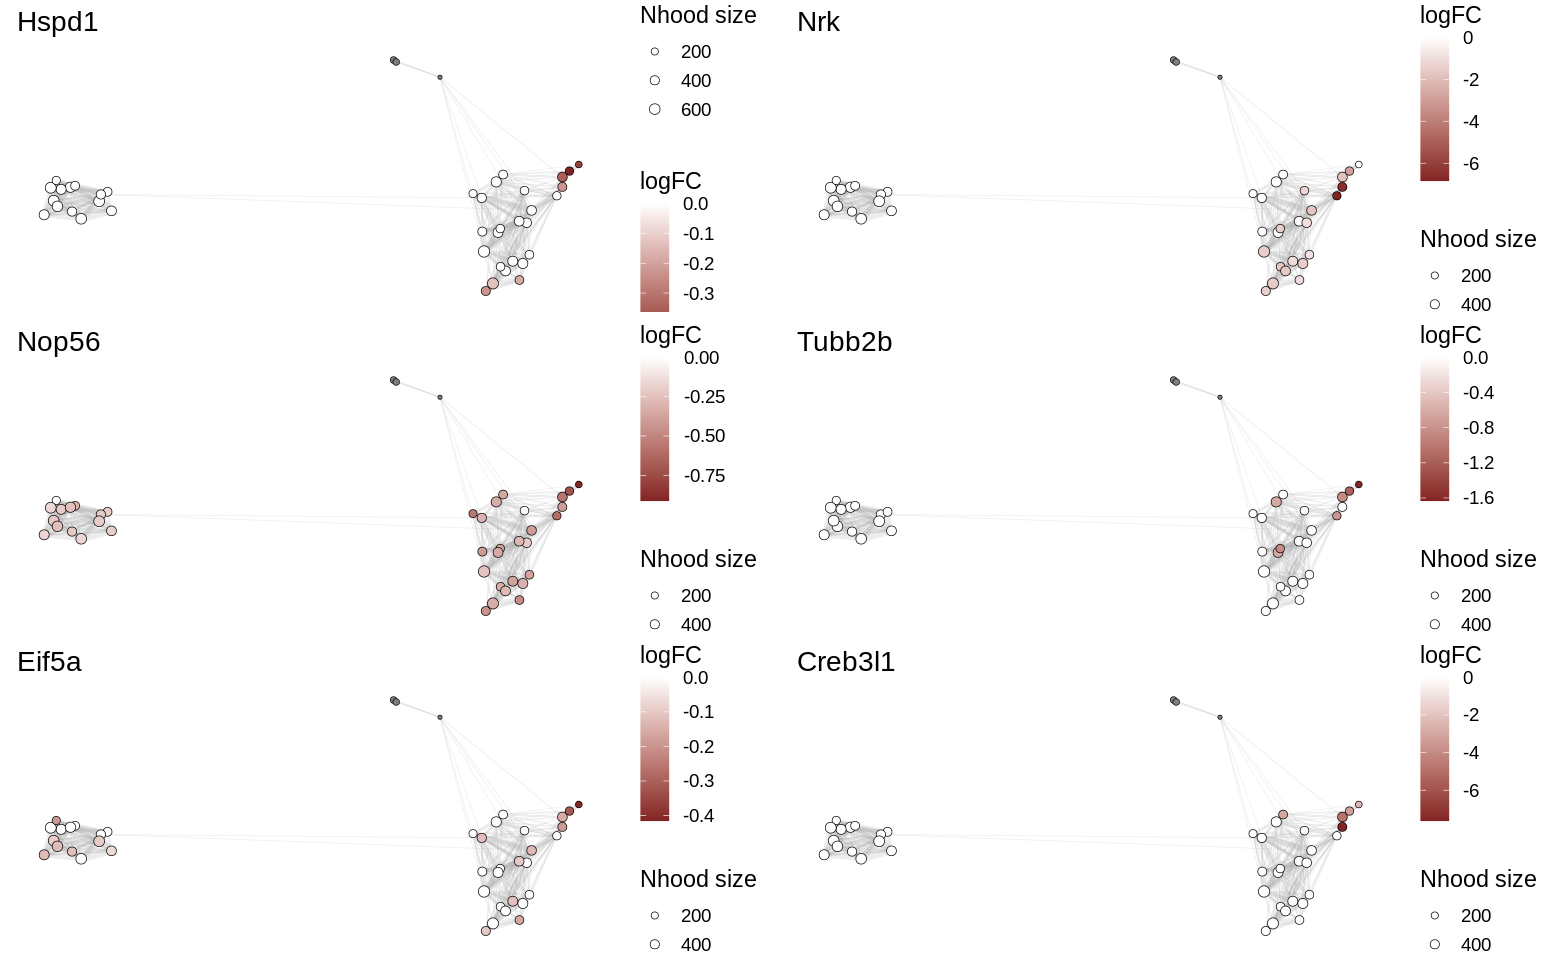

In [70]:

set.seed(1020)
module = 4
n_genes = 6
genes = sample(modules_wgcna$gene[modules_wgcna$cluster == module] , n_genes)


plots = lapply(genes , function(gene){
  p = plot_DE_single_gene(sce_milo, de_stat , gene = gene , layout = "UMAP" , set_na_to_0 = TRUE) + 
    ggtitle(gene)
  return(p)
})
#> Converting de_stat to 'data.frame' format
#> Warning in plot_milo_by_single_metric(x, nhood_stat = nhood_stat, colour_by =
#> "logFC", : Coercing layout to matrix format
#> Converting de_stat to 'data.frame' format
#> Warning in plot_milo_by_single_metric(x, nhood_stat = nhood_stat, colour_by =
#> "logFC", : Coercing layout to matrix format
#> Converting de_stat to 'data.frame' format
#> Warning in plot_milo_by_single_metric(x, nhood_stat = nhood_stat, colour_by =
#> "logFC", : Coercing layout to matrix format
#> Converting de_stat to 'data.frame' format
#> Warning in plot_milo_by_single_metric(x, nhood_stat = nhood_stat, colour_by =
#> "logFC", : Coercing layout to matrix format
#> Converting de_stat to 'data.frame' format
#> Warning in plot_milo_by_single_metric(x, nhood_stat = nhood_stat, colour_by =
#> "logFC", : Coercing layout to matrix format
#> Converting de_stat to 'data.frame' format
#> Warning in plot_milo_by_single_metric(x, nhood_stat = nhood_stat, colour_by =
#> "logFC", : Coercing layout to matrix format
p = ggarrange(plotlist = plots, ncol=2, nrow=3)
p